In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.cm as cm
from matplotlib.cm import ScalarMappable
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.animation as animation


import scipy
import numpy as np
import pandas as pd

from pathlib import Path
import soundfile as sf
from tqdm import tqdm
from sklearn.cluster import KMeans
import scipy.signal as signal
import scipy.special as special

In [2]:
import sys

# append the path of the
# parent directory
sys.path.append('..')
sys.path.append('../src/')
sys.path.append('../src/models/bat_call_detector/batdetect2/')

import src.batdt2_pipeline as batdetect2_pipeline
from pipeline import pipeline
from cfg import get_config

import bout_clustering as clstr

In [3]:
C = 343 # m/s speed of sound in air
FS = 250000
SNR_CALC_LENGTH = 0.030
SNR_OFFSET_BEFORE_CALL = 0.015
TIME_PAD_FOR_ECHO = 0.002
CORR_LENGTH = 0.025
SELECTED_CHANNEL_FOR_REF = 7
NUM_CHANNELS_TOTAL = 8
FILE_DURATION = 120
HOUR_TAG = 'hour_0'
ZMAG_REF_TO_6 = 46.5625
ZMAG_REF_TO_1 = 35.5
XMAG_REF_TO_1 = 17.7
YMAG_REF_TO_6 = 21
YMAG_REF_TO_1 = 37.5
A_LOCS_MAT = np.array([[-XMAG_REF_TO_1, YMAG_REF_TO_1, -ZMAG_REF_TO_1],
                    [-XMAG_REF_TO_1, -YMAG_REF_TO_1, -ZMAG_REF_TO_1],
                    [-XMAG_REF_TO_1, YMAG_REF_TO_1, 0],
                    [-XMAG_REF_TO_1, -YMAG_REF_TO_1, 0],
                    [-XMAG_REF_TO_1, YMAG_REF_TO_6, ZMAG_REF_TO_6],
                    [-XMAG_REF_TO_1, -YMAG_REF_TO_6, ZMAG_REF_TO_6],
                    [0, 0, -ZMAG_REF_TO_1],
                    [0, 0, 0]])

In [4]:
import UBNA_localize_process_GCC as localize

In [5]:
%matplotlib inline

microphones_used = np.array([1, 3, 4, 5, 6, 7, 8])
ind_of_selected_channel = np.where(microphones_used==(SELECTED_CHANNEL_FOR_REF+1))[0]
SELECTED_MIC_FOR_REF = microphones_used[ind_of_selected_channel]
non_ref_microphones_used = microphones_used[microphones_used!=SELECTED_MIC_FOR_REF]
num_good_channels = microphones_used.shape[0]
num_nonref_channels = num_good_channels-1

file_dir = Path('/Volumes/Elements/UBNA_array_tests/mic_array_test_20241010/inUBNA/array')
site_key = 'Telephone'
freq_key = ''

data_params = dict()
data_params['site_tag'] = site_key
data_params['type_tag'] = freq_key
data_params['detector_tag'] = 'bd2'
data_params['assembly_type'] = 'kmeans'
file_paths = dict()
file_paths["SITE_folder"] = f'/Users/adityakrishna/duty-cycle-investigation/data/2022_detector_summaries/{data_params["site_tag"]}'
file_paths["detector_TYPE_SITE_YEAR"] = f'{data_params["detector_tag"]}__{data_params["type_tag"]}{data_params["site_tag"]}_2022_{data_params["assembly_type"]}'
location_df = pd.read_csv(f'{file_paths["SITE_folder"]}/{file_paths["detector_TYPE_SITE_YEAR"]}.csv', index_col=0, low_memory=False)
bout_params = clstr.get_bout_params_from_location(location_df, data_params)
bout_params

{'site_key': 'Telephone',
 'HF_bci': 4640.588823870457,
 'LF_bci': 5004.35931804827}

Currently at /Volumes/Elements/UBNA_array_tests/mic_array_test_20241010/inUBNA/array/hour_0_1800to1920/hour_0_channel7_1800to1920.WAV


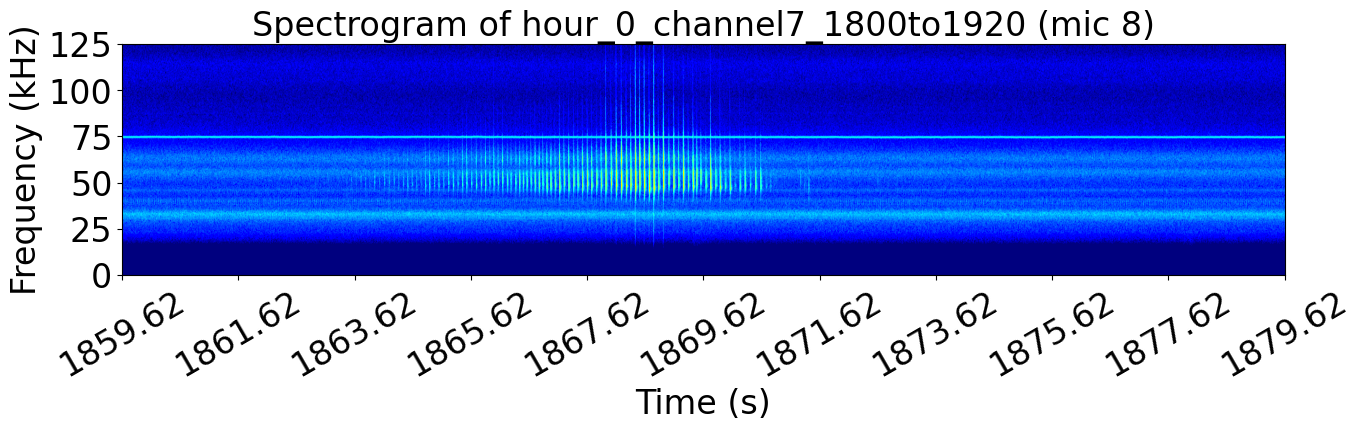

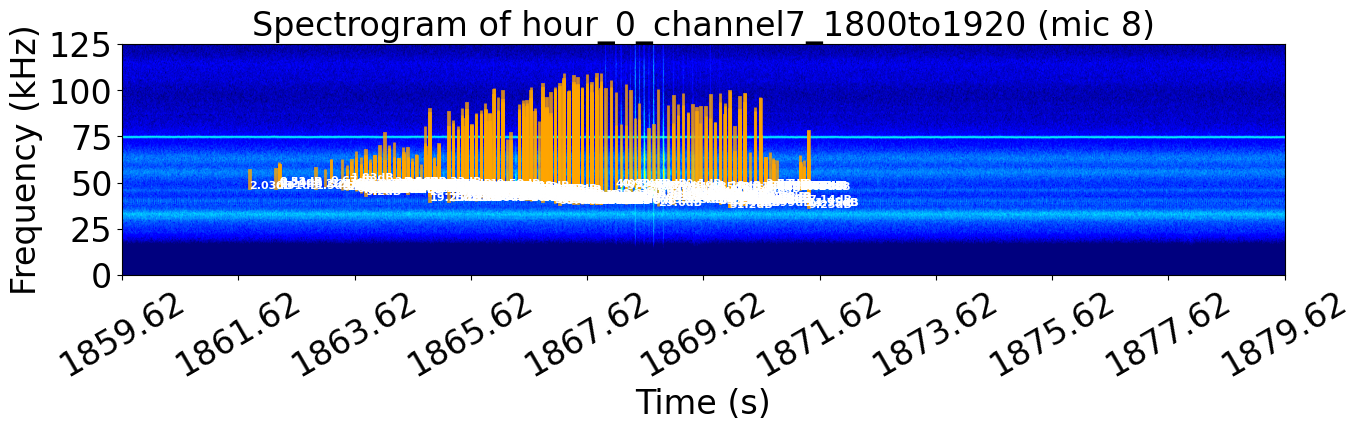

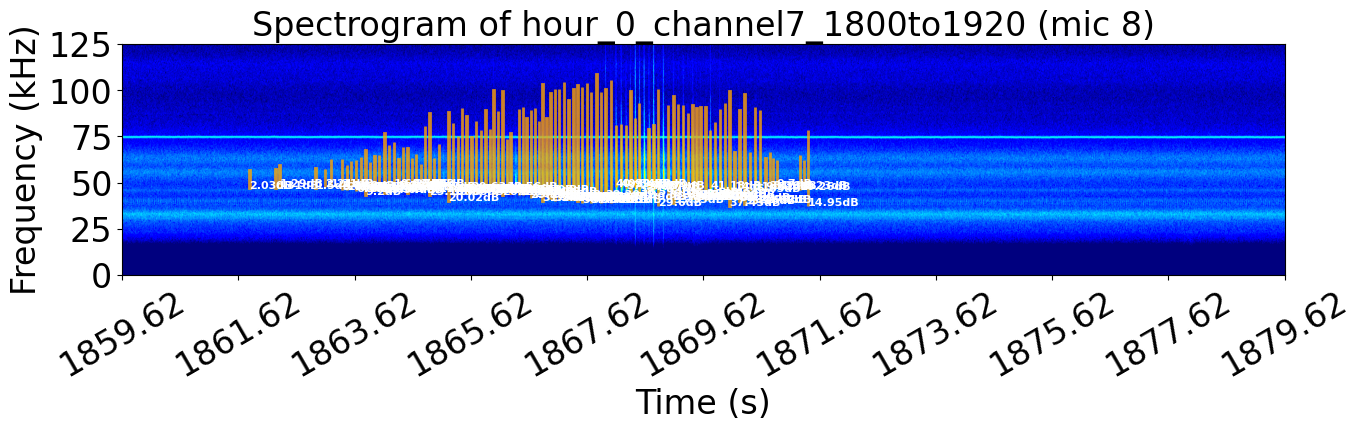

In [6]:
%matplotlib inline

file_offset = 1800
FILE_TIME_TAG = f'{int(file_offset)}to{int(file_offset+FILE_DURATION)}'
dir_name = f'{HOUR_TAG}_{FILE_TIME_TAG}'
write_dir = file_dir / dir_name

channel_dets = localize.get_dets_observed_from_all_channels(microphones_used, file_dir, file_offset)
channel_dets.sort_values(by='start_time', inplace=True)
channel_dets.reset_index(drop=True, inplace=True)
removed_overlaps = localize.remove_overlapping_events(channel_dets, time_threshold=0.01)
snr_thresh_dets = removed_overlaps[removed_overlaps['SNR']>=0].copy()
tagged_dets = clstr.classify_bouts_in_detector_preds_for_freqgroups(snr_thresh_dets, bout_params)
bout_metrics = clstr.construct_bout_metrics_from_location_df_for_freqgroups(tagged_dets)
write_file = write_dir / f'{HOUR_TAG}_channel{SELECTED_CHANNEL_FOR_REF}_{FILE_TIME_TAG}.WAV'

bout = bout_metrics.iloc[0]
start = bout['start_time'] - file_offset - (bout['bout_duration_in_secs']*(1.5/6.6))
length = 20
plot_channel_dets = channel_dets.loc[(channel_dets['start_time']>=(file_offset+start))&(channel_dets['end_time']<=(file_offset+start+length))]
plot_dets = removed_overlaps.loc[(removed_overlaps['start_time']>=(file_offset+start))&(removed_overlaps['end_time']<=(file_offset+start+length))]

set_for_tdoa = plot_dets[plot_dets['SNR']>=0].reset_index(drop=True).copy()
localize.plot_audio_bout(write_file, SELECTED_CHANNEL_FOR_REF, start, length, file_offset, plot_channel_dets, set_for_tdoa)

In [7]:
calls_for_tdoa, call_voltage_rms, snr_facs_for_tdoa, det_durs_for_tdoa = localize.find_relevant_tdoa_arrays(set_for_tdoa, microphones_used, file_offset, write_dir)
t_delay_wrt_selected_channel = localize.find_d_mics_to_ref_using_GCC(set_for_tdoa, microphones_used, calls_for_tdoa, snr_facs_for_tdoa, det_durs_for_tdoa)
d_mics_to_ref_meters, A_locs_mat_tdoa_inches = localize.get_d_mics_with_mic_locs(microphones_used, t_delay_wrt_selected_channel, SELECTED_CHANNEL_FOR_REF)
A_locs_mat_tdoa_meters = A_locs_mat_tdoa_inches * (254/10000)

source_points = localize.assemble_source_points_in_meters(d_mics_to_ref_meters, microphones_used, A_locs_mat_tdoa_meters)

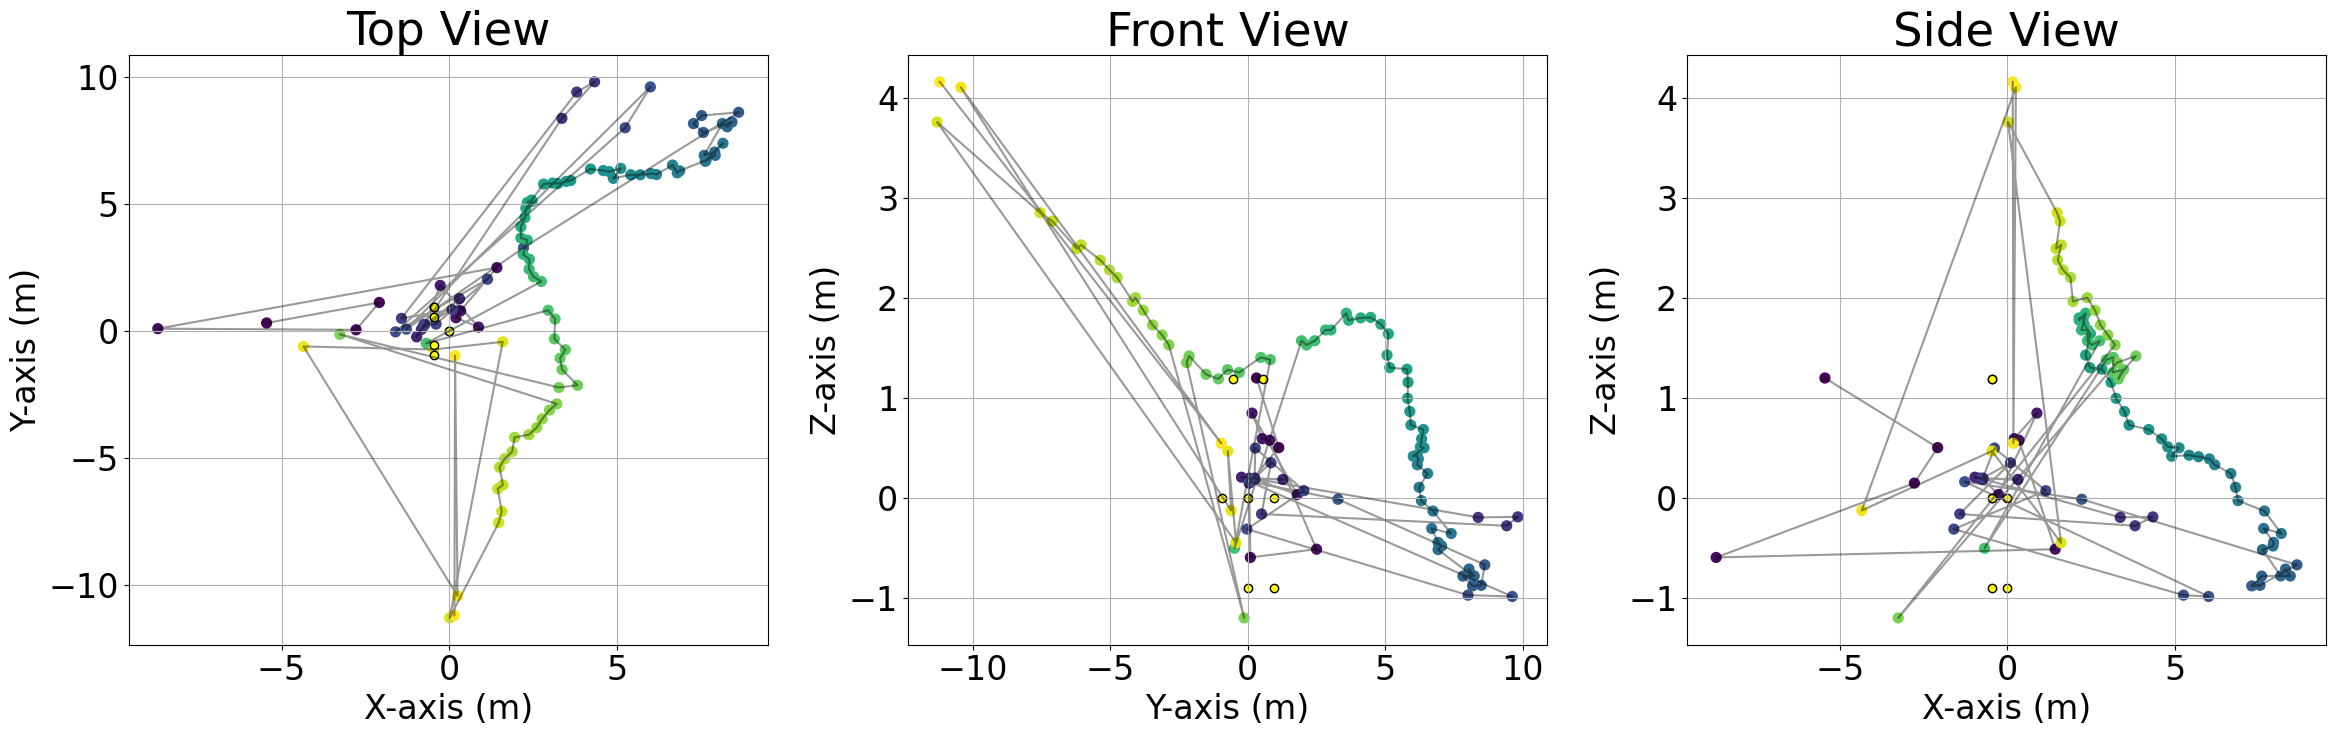

In [8]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 8))
plt.rcParams.update({'font.size':28})
localize.plot_three_plane_trajectories(ax1, ax2, ax3, set_for_tdoa, source_points, source_points, A_locs_mat_tdoa_meters, start, length)
ax1.set_title('Top View')
ax1.grid(which='both')
ax1.set_xlabel('X-axis (m)')
ax1.set_ylabel('Y-axis (m)')

ax2.set_title('Front View')
ax2.grid(which='both')
ax2.set_xlabel('Y-axis (m)')
ax2.set_ylabel('Z-axis (m)')

ax3.set_title('Side View')
ax3.grid(which='both')
ax3.set_xlabel('X-axis (m)')
ax3.set_ylabel('Z-axis (m)')

plt.tight_layout()
plt.show()

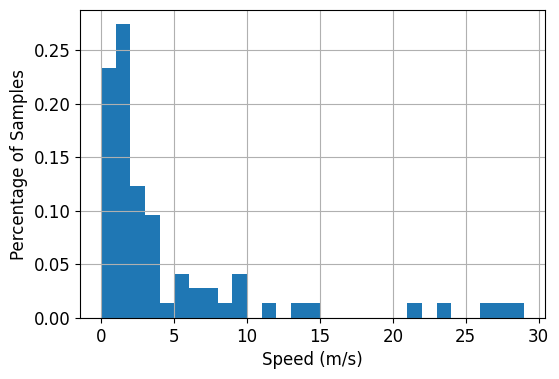

In [9]:
dist_travel_per_point = ((source_points[:,1:] - source_points[:,:-1])**2)[:3,:].sum(axis=0)
time_between_points = (set_for_tdoa['end_time'][1:].values - set_for_tdoa['start_time'][:-1].values)
speed_between_points = dist_travel_per_point / time_between_points

plt.figure(figsize=(6,4))
plt.rcParams.update({'font.size':12})
plt.hist(speed_between_points, bins=np.arange(0,30,1), density=True)
plt.ylabel('Percentage of Samples')
plt.xlabel('Speed (m/s)')
plt.grid(which='both')
plt.show()

In [10]:
e1 = -0.6
e2 = 0
a = 1.5
b = 1

speed_threshold = 8
dets_with_valid_speeds = set_for_tdoa[np.concatenate([[speed_threshold], speed_between_points])<speed_threshold]
src_points_with_valid_speeds = source_points[:,np.concatenate([[speed_threshold], speed_between_points])<speed_threshold]
source_x_coords = src_points_with_valid_speeds[0,:]
source_y_coords = src_points_with_valid_speeds[1,:]
distance_of_points_from_ellipse = (((source_x_coords - e1) / a)**2) + (((source_y_coords - e2) / b)**2)

valid_dets_outside_unit_circle = dets_with_valid_speeds[distance_of_points_from_ellipse>1]
valid_speed_src_points_outside_unit_circle = src_points_with_valid_speeds[:,distance_of_points_from_ellipse>1]

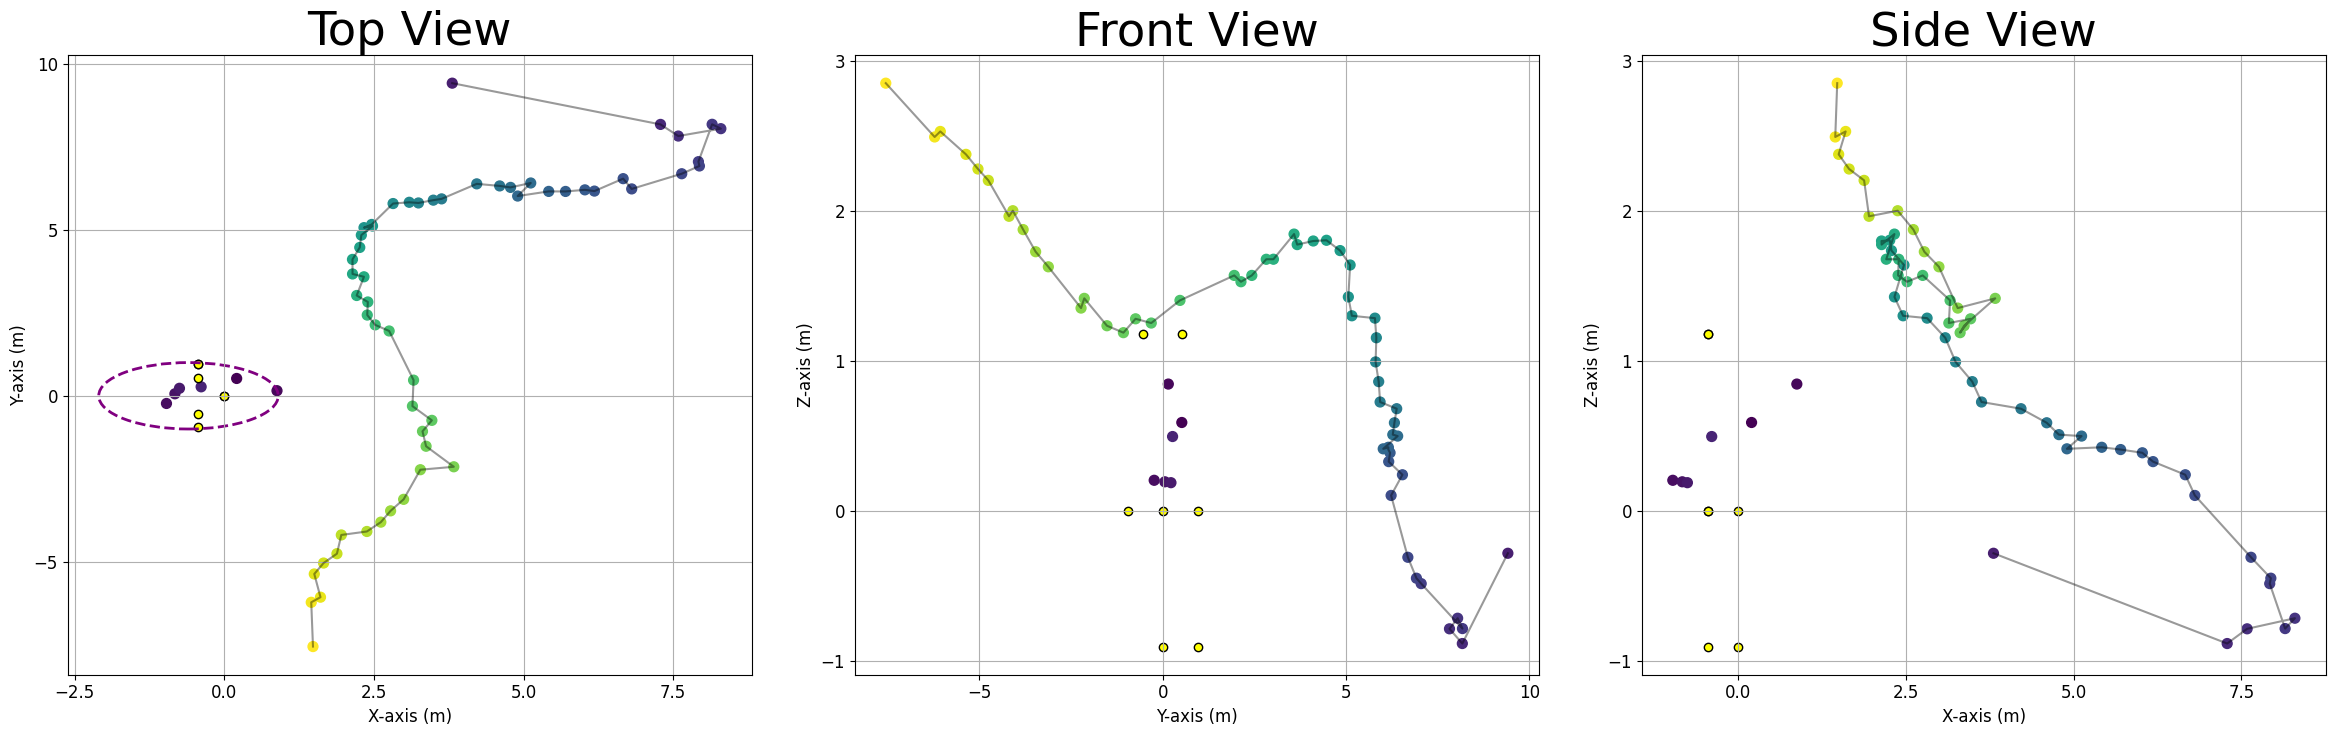

In [11]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 8))
plt.rcParams.update({'font.size':28})
localize.plot_three_plane_trajectories(ax1, ax2, ax3, valid_dets_outside_unit_circle, valid_speed_src_points_outside_unit_circle, 
                                       src_points_with_valid_speeds, A_locs_mat_tdoa_meters, start, length)
ax1.set_title('Top View')
ax1.grid(which='both')
ax1.set_xlabel('X-axis (m)')
ax1.set_ylabel('Y-axis (m)')
ellipse = patches.Ellipse((e1, e2), width=2*a, height=2*b, edgecolor="purple", facecolor="none", linestyle="--", linewidth=2)
ax1.add_patch(ellipse)

ax2.set_title('Front View')
ax2.grid(which='both')
ax2.set_xlabel('Y-axis (m)')
ax2.set_ylabel('Z-axis (m)')

ax3.set_title('Side View')
ax3.grid(which='both')
ax3.set_xlabel('X-axis (m)')
ax3.set_ylabel('Z-axis (m)')

plt.tight_layout()
plt.show()

In [12]:
def plot_dB_labels_2d(ax, x_axis, y_axis, map_vals):
    for i in np.linspace(0, x_axis.shape[0]-1, 11).astype(int):
        scale = 0.3
        t_x, t_y = x_axis[i]+scale, y_axis[i]+scale
        ax.text(x=t_x, y=t_y, s=f'{round(map_vals[i], 1)}dB', fontsize=14)

def convertVtoRL(observed_voltage_rms, sens_dB, mic_gain_dB_at_f, preamp_gain):
    preamp_gain_dB = 20*np.log10(preamp_gain)
    receive_voltage_dB = 20*np.log10(observed_voltage_rms) -  preamp_gain_dB
    RL_dB_with_mic_sensitivity = receive_voltage_dB - mic_gain_dB_at_f
    RL_dB_re_20uPa = RL_dB_with_mic_sensitivity - sens_dB - 20*np.log10(20e-6)

    return RL_dB_re_20uPa

def absorption(f, t=20, rh=60):
    """ In dB/m
    
        f: frequency in Hz
        t: temperature in °C
        rh: relative humidity in %
        ps: atmospheric pressure in Pa

        From http://en.wikibooks.org/wiki/Engineering_Acoustics/Outdoor_Sound_Propagation
        See __main__ for actual curves.
    """
    ## 1 atm in Pa
    ps0 = 1.01325e5
    ps = ps0

    if type(f) != int:
        f = f.reshape(1, len(f))
    if type(t) != int:
        t = t.reshape(len(t), 1)
    if type(rh) != int:
        rh = rh.reshape(len(rh), 1)
    T = t + 273.15
    T0 = 293.15
    T01 = 273.16

    Csat = -6.8346 * np.power(T01 / T, 1.261) + 4.6151
    rhosat = np.power(10, Csat)
    H = rhosat * rh * ps0 / ps

    frn = (ps / ps0) * np.power(T0 / T, 0.5) * (
            9 + 280 * H * np.exp(-4.17 * (np.power(T0 / T, 1/3.) - 1)))

    fro = (ps / ps0) * (24.0 + 4.04e4 * H * (0.02 + H) / (0.391 + H))

    alpha = f * f * (
        1.84e-11 / ( np.power(T0 / T, 0.5) * ps / ps0 )
        + np.power(T / T0, -2.5)
        * (
            0.10680 * np.exp(-3352 / T) * frn / (f * f + frn * frn)
            + 0.01278 * np.exp(-2239.1 / T) * fro / (f * f + fro * fro)
            )
        )

    return 20 * alpha / np.log(10)

Currently at /Volumes/Elements/UBNA_array_tests/mic_array_test_20241010/inUBNA/array/hour_0_1800to1920/hour_0_channel7_1800to1920.WAV


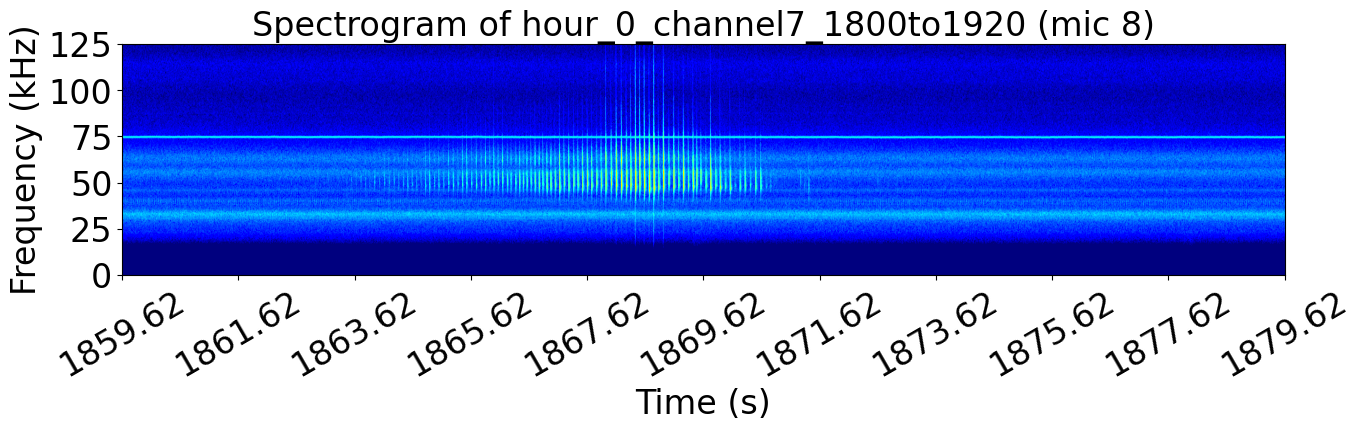

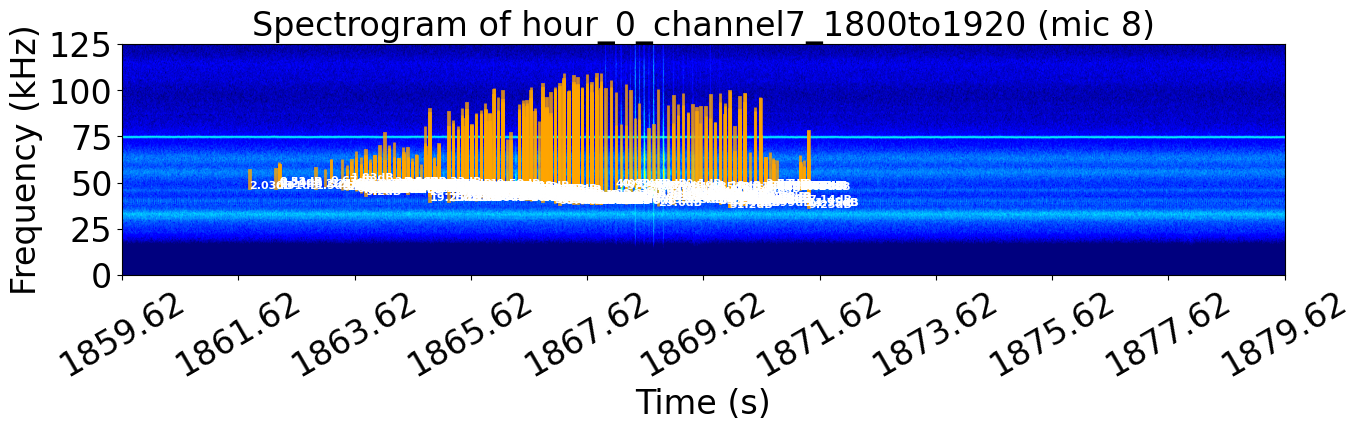

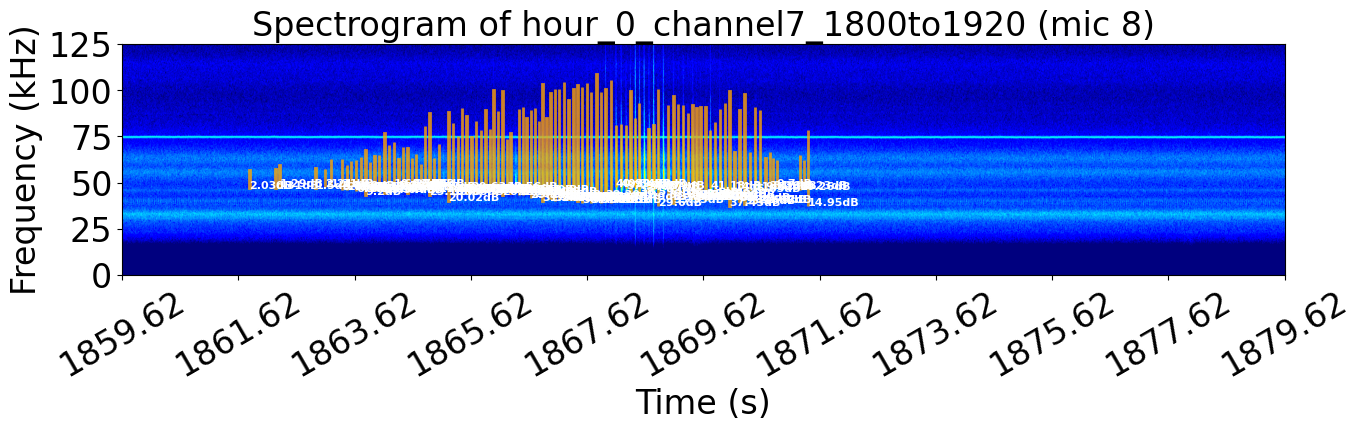

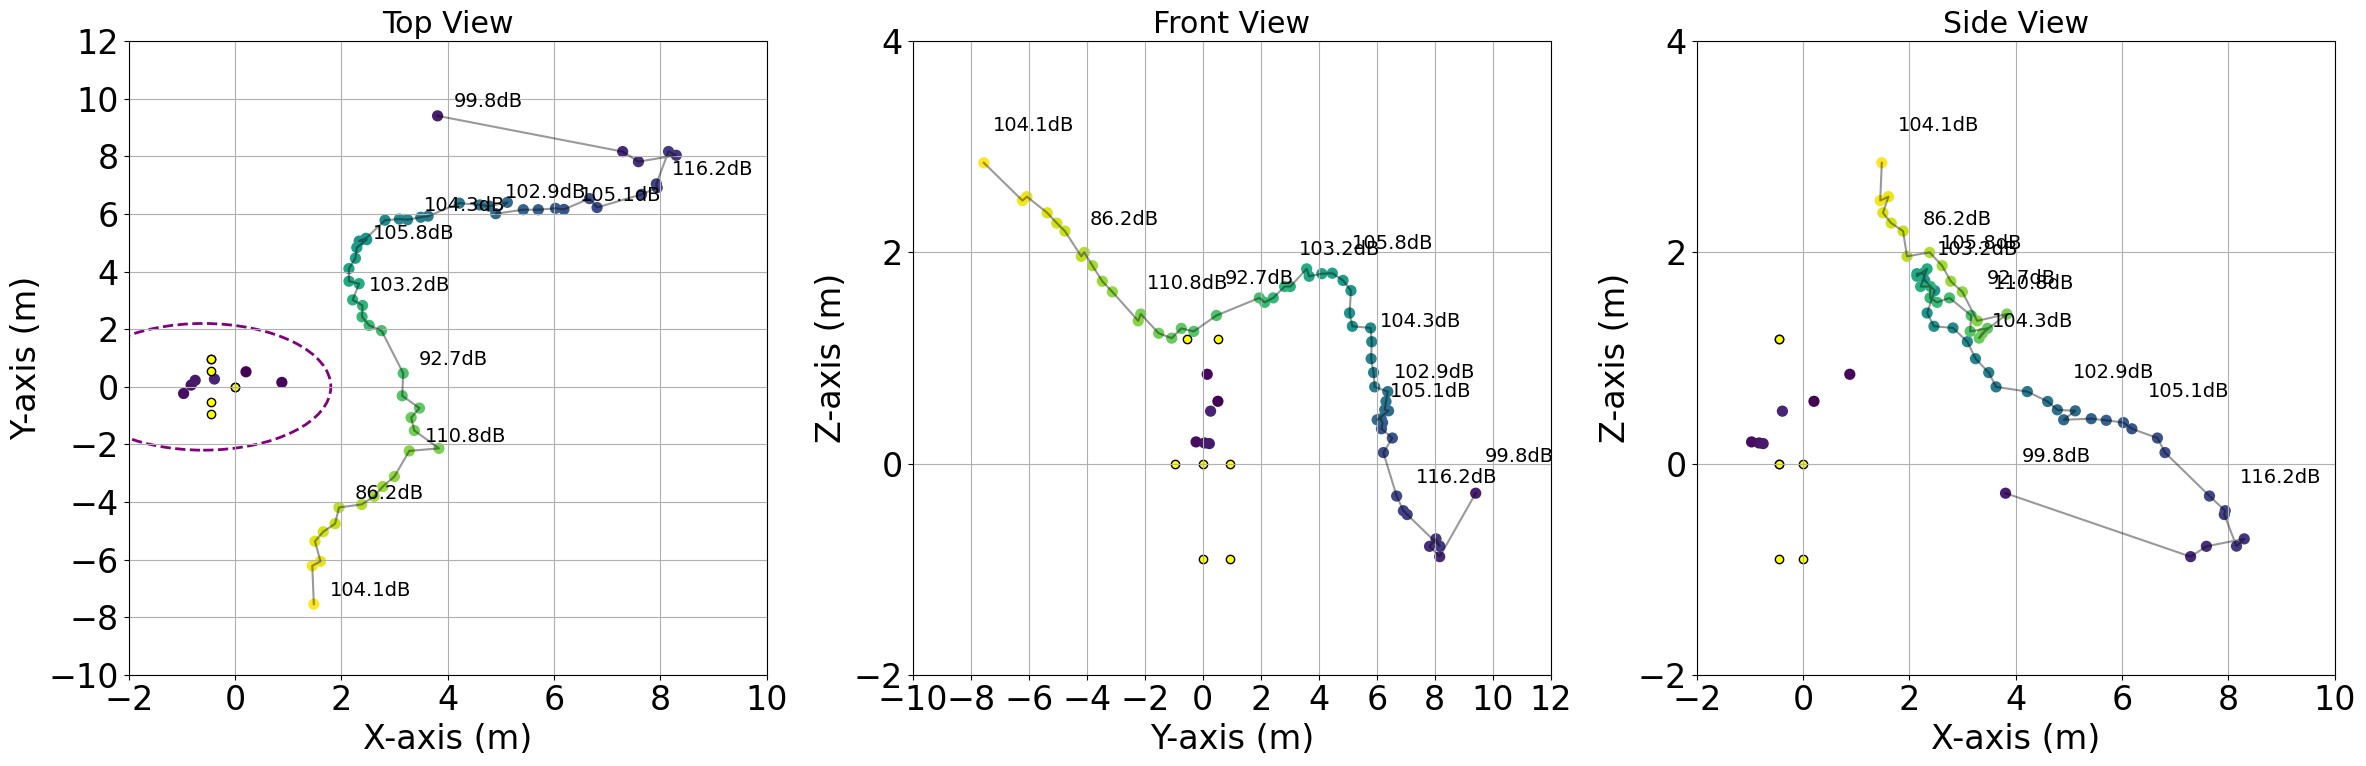

In [13]:
%matplotlib inline

file_offset = 1800
FILE_TIME_TAG = f'{int(file_offset)}to{int(file_offset+FILE_DURATION)}'
dir_name = f'{HOUR_TAG}_{FILE_TIME_TAG}'
write_dir = file_dir / dir_name

channel_dets = localize.get_dets_observed_from_all_channels(microphones_used, file_dir, file_offset)
channel_dets.sort_values(by='start_time', inplace=True)
channel_dets.reset_index(drop=True, inplace=True)
removed_overlaps = localize.remove_overlapping_events(channel_dets, time_threshold=0.01)
snr_thresh_dets = removed_overlaps[removed_overlaps['SNR']>=0].copy()
tagged_dets = clstr.classify_bouts_in_detector_preds_for_freqgroups(snr_thresh_dets, bout_params)
bout_metrics = clstr.construct_bout_metrics_from_location_df_for_freqgroups(tagged_dets)
write_file = write_dir / f'{HOUR_TAG}_channel{SELECTED_CHANNEL_FOR_REF}_{FILE_TIME_TAG}.WAV'

bout = bout_metrics.iloc[0]
start = bout['start_time'] - file_offset - (bout['bout_duration_in_secs']*(1.5/6.6))
length = 20
plot_channel_dets = channel_dets.loc[(channel_dets['start_time']>=(file_offset+start))&(channel_dets['end_time']<=(file_offset+start+length))]
plot_dets = removed_overlaps.loc[(removed_overlaps['start_time']>=(file_offset+start))&(removed_overlaps['end_time']<=(file_offset+start+length))]

set_for_tdoa = plot_dets[plot_dets['SNR']>=0].reset_index(drop=True).copy()
localize.plot_audio_bout(write_file, SELECTED_CHANNEL_FOR_REF, start, length, file_offset, plot_channel_dets, set_for_tdoa)

calls_for_tdoa, call_voltage_rms, snr_facs_for_tdoa, det_durs_for_tdoa = localize.find_relevant_tdoa_arrays(set_for_tdoa, microphones_used, file_offset, write_dir)
t_delay_wrt_selected_channel = localize.find_d_mics_to_ref_using_GCC(set_for_tdoa, microphones_used, calls_for_tdoa, snr_facs_for_tdoa, det_durs_for_tdoa)
d_mics_to_ref_meters, A_locs_mat_tdoa_inches = localize.get_d_mics_with_mic_locs(microphones_used, t_delay_wrt_selected_channel, SELECTED_CHANNEL_FOR_REF)
A_locs_mat_tdoa_meters = A_locs_mat_tdoa_inches * (254/10000)

source_points = localize.assemble_source_points_in_meters(d_mics_to_ref_meters, microphones_used, A_locs_mat_tdoa_meters)
dist_travel_per_point = ((source_points[:,1:] - source_points[:,:-1])**2)[:3,:].sum(axis=0)
time_between_points = (set_for_tdoa['end_time'][1:].values - set_for_tdoa['start_time'][:-1].values)
speed_between_points = dist_travel_per_point / time_between_points

e1 = -0.6
e2 = 0
ellpse_hori_radius = 2.4
ellpse_vert_radius = 2.2

speed_threshold = 8
speed_based_indices = np.concatenate([[speed_threshold], speed_between_points])<speed_threshold
dets_with_valid_speeds = set_for_tdoa[speed_based_indices]
src_points_with_valid_speeds = source_points[:,speed_based_indices]
source_x_coords = src_points_with_valid_speeds[0,:]
source_y_coords = src_points_with_valid_speeds[1,:]
distance_of_points_from_ellipse = (((source_x_coords - e1) / ellpse_hori_radius)**2) + (((source_y_coords - e2) / ellpse_vert_radius)**2)

ellipse_based_indices = distance_of_points_from_ellipse>1
valid_dets_outside_unit_circle = dets_with_valid_speeds[ellipse_based_indices]
valid_speed_src_points_outside_unit_circle = src_points_with_valid_speeds[:,ellipse_based_indices]

a = 0.003
wavelength = C / valid_dets_outside_unit_circle['peak_frequency'].values
k = 2*np.pi/wavelength
ka = k*a
theta = np.pi/2

dist_bat_from_ref_mic = np.sqrt(np.sum(valid_speed_src_points_outside_unit_circle[:3,:]**2, axis=0))
call_vrms_vals = call_voltage_rms[speed_based_indices, ind_of_selected_channel][ellipse_based_indices]
RL_dB_re_20uPa = convertVtoRL(call_vrms_vals, -38, 12, 200)
### Atmospheric attenuation found usinh Jakobsen at. al 2013
atmos_loss_DB = absorption(valid_dets_outside_unit_circle['peak_frequency'].values)*dist_bat_from_ref_mic
### Geometric Spreading calculated using Jakobsen et. al 2013
spreading_dB = 20*np.log10(dist_bat_from_ref_mic)
D_theta = 2*special.j1(ka*np.sin(theta))/(ka*np.sin(theta))
D_theta_dB = -20*np.log10(np.abs(D_theta))
TL_dB = atmos_loss_DB+spreading_dB+D_theta_dB
bat_SL_dB_re_20uPa = RL_dB_re_20uPa + TL_dB

delta_t = valid_dets_outside_unit_circle['start_time'][1:].reset_index(drop=True) - valid_dets_outside_unit_circle['end_time'][:-1].reset_index(drop=True)
delta_x = (valid_speed_src_points_outside_unit_circle[0,1:] - valid_speed_src_points_outside_unit_circle[0,:-1])
delta_y = (valid_speed_src_points_outside_unit_circle[1,1:] - valid_speed_src_points_outside_unit_circle[1,:-1])
delta_z = (valid_speed_src_points_outside_unit_circle[2,1:] - valid_speed_src_points_outside_unit_circle[2,:-1])
delta_dist = ((delta_x**2) + (delta_y**2) + (delta_z**2))**0.5

flight_speed_per_2points = (delta_dist/delta_t.values)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 8))
plt.rcParams.update({'font.size':18})
localize.plot_three_plane_trajectories(ax1, ax2, ax3, valid_dets_outside_unit_circle, valid_speed_src_points_outside_unit_circle, 
                                       src_points_with_valid_speeds, A_locs_mat_tdoa_meters, start, length)
ax1.set_title('Top View')
ax1.grid(which='both')
ax1.set_xlabel('X-axis (m)')
ax1.set_ylabel('Y-axis (m)')
ellipse = patches.Ellipse((e1, e2), width=2*ellpse_hori_radius, height=2*ellpse_vert_radius, edgecolor="purple", facecolor="none", linestyle="--", linewidth=2)
ax1.add_patch(ellipse)
plot_dB_labels_2d(ax1, valid_speed_src_points_outside_unit_circle[0,:], valid_speed_src_points_outside_unit_circle[1,:], bat_SL_dB_re_20uPa[0])
ax1.set_xlim(-2, 10)
ax1.set_ylim(-10, 12)
ax1.set_xticks(np.arange(-2, 12, 2))
ax1.set_yticks(np.arange(-10, 14, 2))

ax2.set_title('Front View')
ax2.grid(which='both')
ax2.set_xlabel('Y-axis (m)')
ax2.set_ylabel('Z-axis (m)')
plot_dB_labels_2d(ax2, valid_speed_src_points_outside_unit_circle[1,:], valid_speed_src_points_outside_unit_circle[2,:], bat_SL_dB_re_20uPa[0])
ax2.set_xlim(-10, 12)
ax2.set_ylim(-2, 4)
ax2.set_xticks(np.arange(-10, 14, 2))
ax2.set_yticks(np.arange(-2, 6, 2))

ax3.set_title('Side View')
ax3.grid(which='both')
ax3.set_xlabel('X-axis (m)')
ax3.set_ylabel('Z-axis (m)')
plot_dB_labels_2d(ax3, valid_speed_src_points_outside_unit_circle[0,:], valid_speed_src_points_outside_unit_circle[2,:], bat_SL_dB_re_20uPa[0])
ax3.set_xlim(-2, 10)
ax3.set_ylim(-2, 4)
ax3.set_xticks(np.arange(-2, 12, 2))
ax3.set_yticks(np.arange(-2, 6, 2))

fig.tight_layout()
plt.show()

Animation saved as 20241215__UBNA1010deployment_3d_trajectory_1800.mp4


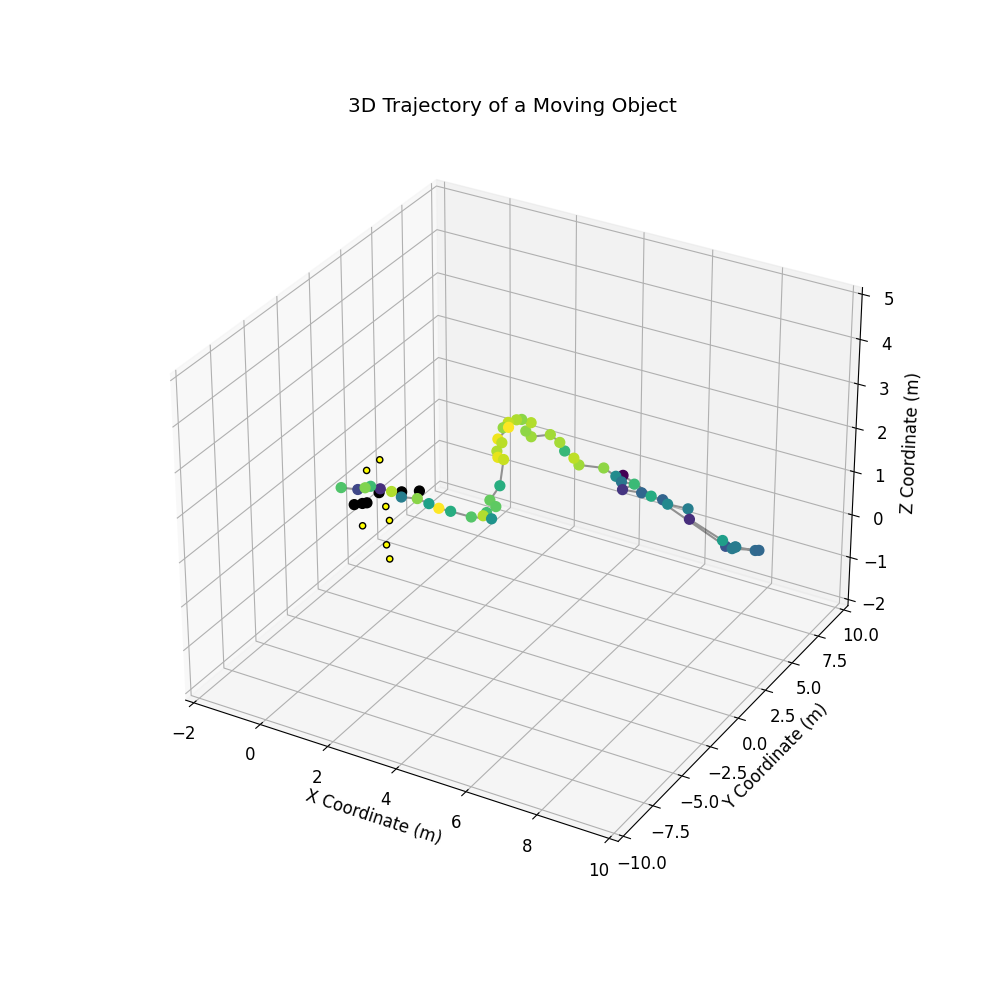

In [14]:
%matplotlib widget

fig = plt.figure(figsize=(10, 10))
plt.rcParams.update({'font.size': 12})
ax = fig.add_subplot(projection='3d')
ax.cla()

cmap = plt.get_cmap('viridis')
map_vals = (valid_dets_outside_unit_circle['SNR'])
color_vals = np.linspace(start, start+length, src_points_with_valid_speeds.shape[1])
norm = plt.Normalize(map_vals.min(), map_vals.max())
line_colors = cmap(norm(map_vals))

scatter = ax.scatter([], [], [], alpha=1, s=50)
line, = ax.plot([], [], [], color='k', alpha=0.4)

def update(frame):
    ax.cla()  # Clear the axis
    
    # Redraw the scatter points up to the current frame
    ax.scatter(
        valid_speed_src_points_outside_unit_circle[0, :frame],
        valid_speed_src_points_outside_unit_circle[1, :frame],
        valid_speed_src_points_outside_unit_circle[2, :frame],
        color=line_colors[:frame],
        alpha=1,
        s=50,
    )
    
    # Redraw the trajectory line up to the current frame
    ax.plot(
        valid_speed_src_points_outside_unit_circle[0, :frame],
        valid_speed_src_points_outside_unit_circle[1, :frame],
        valid_speed_src_points_outside_unit_circle[2, :frame],
        color='k',
        alpha=0.4,
    )

    ax.scatter(src_points_with_valid_speeds[0, ~ellipse_based_indices], src_points_with_valid_speeds[1, ~ellipse_based_indices],
        src_points_with_valid_speeds[2, ~ellipse_based_indices], color='k', alpha=1, s=50)
    ax.scatter(xs=A_locs_mat_tdoa_meters[:,0], ys=A_locs_mat_tdoa_meters[:,1], zs=A_locs_mat_tdoa_meters[:,2], facecolor='yellow', edgecolor='k', alpha=1)
    ax.scatter(xs=0, ys=0, zs=0, facecolor='yellow', edgecolor='k', alpha=1)
    
    # Restore axis labels and title after clearing
    ax.set_xlabel('X Coordinate (m)')
    ax.set_ylabel('Y Coordinate (m)')
    ax.set_zlabel('Z Coordinate (m)')
    ax.set_title('3D Trajectory of a Moving Object')
    ax.set_xlim([-2, 10])
    ax.set_ylim([-10, 10])
    ax.set_zlim([-2, 5])


num_frames = src_points_with_valid_speeds.shape[1]
ani = animation.FuncAnimation(fig, update, frames=num_frames, interval=50)

video_filename = f'20241215__UBNA1010deployment_3d_trajectory_{file_offset}.mp4'
ani.save(video_filename, writer='ffmpeg', fps=20)

print(f"Animation saved as {video_filename}")
plt.show()

In [17]:
%matplotlib widget

# for file_offset in np.arange(0, 3600, 120):
file_offset = 1680
FILE_TIME_TAG = f'{int(file_offset)}to{int(file_offset+FILE_DURATION)}'
dir_name = f'{HOUR_TAG}_{FILE_TIME_TAG}'
write_dir = file_dir / dir_name

channel_dets = localize.get_dets_observed_from_all_channels(microphones_used, file_dir, file_offset)
channel_dets.sort_values(by='start_time', inplace=True)
channel_dets.reset_index(drop=True, inplace=True)
removed_overlaps = localize.remove_overlapping_events(channel_dets, time_threshold=0.01)
snr_thresh_dets = removed_overlaps[removed_overlaps['SNR']>=0].copy()
tagged_dets = clstr.classify_bouts_in_detector_preds_for_freqgroups(snr_thresh_dets, bout_params)
bout_metrics = clstr.construct_bout_metrics_from_location_df_for_freqgroups(tagged_dets)
write_file = write_dir / f'{HOUR_TAG}_channel{SELECTED_CHANNEL_FOR_REF}_{FILE_TIME_TAG}.WAV'

bout = bout_metrics.iloc[0]
start = bout['start_time'] - file_offset - (bout['bout_duration_in_secs']*(1.5/6.6))
length = min(bout['bout_duration_in_secs']*3, (FILE_DURATION) - start)
plot_channel_dets = channel_dets.loc[(channel_dets['start_time']>=(file_offset+start))&(channel_dets['end_time']<=(file_offset+start+length))]
plot_dets = removed_overlaps.loc[(removed_overlaps['start_time']>=(file_offset+start))&(removed_overlaps['end_time']<=(file_offset+start+length))]

set_for_tdoa = plot_dets[plot_dets['SNR']>=0].reset_index(drop=True).copy()

calls_for_tdoa, call_voltage_rms, snr_facs_for_tdoa, det_durs_for_tdoa = localize.find_relevant_tdoa_arrays(set_for_tdoa, microphones_used, file_offset, write_dir)
t_delay_wrt_selected_channel = localize.find_d_mics_to_ref_using_GCC(set_for_tdoa, microphones_used, calls_for_tdoa, snr_facs_for_tdoa, det_durs_for_tdoa)
d_mics_to_ref_meters, A_locs_mat_tdoa_inches = localize.get_d_mics_with_mic_locs(microphones_used, t_delay_wrt_selected_channel, SELECTED_CHANNEL_FOR_REF)
A_locs_mat_tdoa_meters = A_locs_mat_tdoa_inches * (254/10000)

source_points = localize.assemble_source_points_in_meters(d_mics_to_ref_meters, microphones_used, A_locs_mat_tdoa_meters)
dist_travel_per_point = ((source_points[:,1:] - source_points[:,:-1])**2)[:3,:].sum(axis=0)
time_between_points = (set_for_tdoa['end_time'][1:].values - set_for_tdoa['start_time'][:-1].values)
speed_between_points = dist_travel_per_point / time_between_points

e1 = -0.6
e2 = 0
a = 2.4
b = 2.2

speed_threshold = 8
speed_based_indices = np.concatenate([[speed_threshold], speed_between_points])<speed_threshold
dets_with_valid_speeds = set_for_tdoa[speed_based_indices]
src_points_with_valid_speeds = source_points[:,speed_based_indices]
source_x_coords = src_points_with_valid_speeds[0,:]
source_y_coords = src_points_with_valid_speeds[1,:]
distance_of_points_from_ellipse = (((source_x_coords - e1) / a)**2) + (((source_y_coords - e2) / b)**2)

ellipse_based_indices = distance_of_points_from_ellipse>1
valid_dets_outside_unit_circle = dets_with_valid_speeds[ellipse_based_indices]
valid_speed_src_points_outside_unit_circle = src_points_with_valid_speeds[:,ellipse_based_indices]

a = 0.003
wavelength = C / valid_dets_outside_unit_circle['peak_frequency'].values
k = 2*np.pi/wavelength
ka = k*a
theta = np.pi/2

dist_bat_from_ref_mic = np.sqrt(np.sum(valid_speed_src_points_outside_unit_circle[:3,:]**2, axis=0))
call_vrms_vals = call_voltage_rms[speed_based_indices, ind_of_selected_channel][ellipse_based_indices]
RL_dB_re_20uPa = convertVtoRL(call_vrms_vals, -38, 12, 200)
### Atmospheric attenuation found usinh Jakobsen at. al 2013
atmos_loss_DB = absorption(valid_dets_outside_unit_circle['peak_frequency'].values)*dist_bat_from_ref_mic
### Geometric Spreading calculated using Jakobsen et. al 2013
spreading_dB = 20*np.log10(dist_bat_from_ref_mic)
D_theta = 2*special.j1(ka*np.sin(theta))/(ka*np.sin(theta))
D_theta_dB = -20*np.log10(np.abs(D_theta))
TL_dB = atmos_loss_DB+spreading_dB+D_theta_dB
bat_SL_dB_re_20uPa = RL_dB_re_20uPa + TL_dB

delta_t = valid_dets_outside_unit_circle['start_time'][1:].reset_index(drop=True) - valid_dets_outside_unit_circle['end_time'][:-1].reset_index(drop=True)
delta_x = (valid_speed_src_points_outside_unit_circle[0,1:] - valid_speed_src_points_outside_unit_circle[0,:-1])
delta_y = (valid_speed_src_points_outside_unit_circle[1,1:] - valid_speed_src_points_outside_unit_circle[1,:-1])
delta_z = (valid_speed_src_points_outside_unit_circle[2,1:] - valid_speed_src_points_outside_unit_circle[2,:-1])
delta_dist = ((delta_x**2) + (delta_y**2) + (delta_z**2))**0.5

flight_speed_per_2points = (delta_dist/delta_t.values)

Animation saved as 20241215__UBNA1010deployment_3d_trajectory_1680.mp4


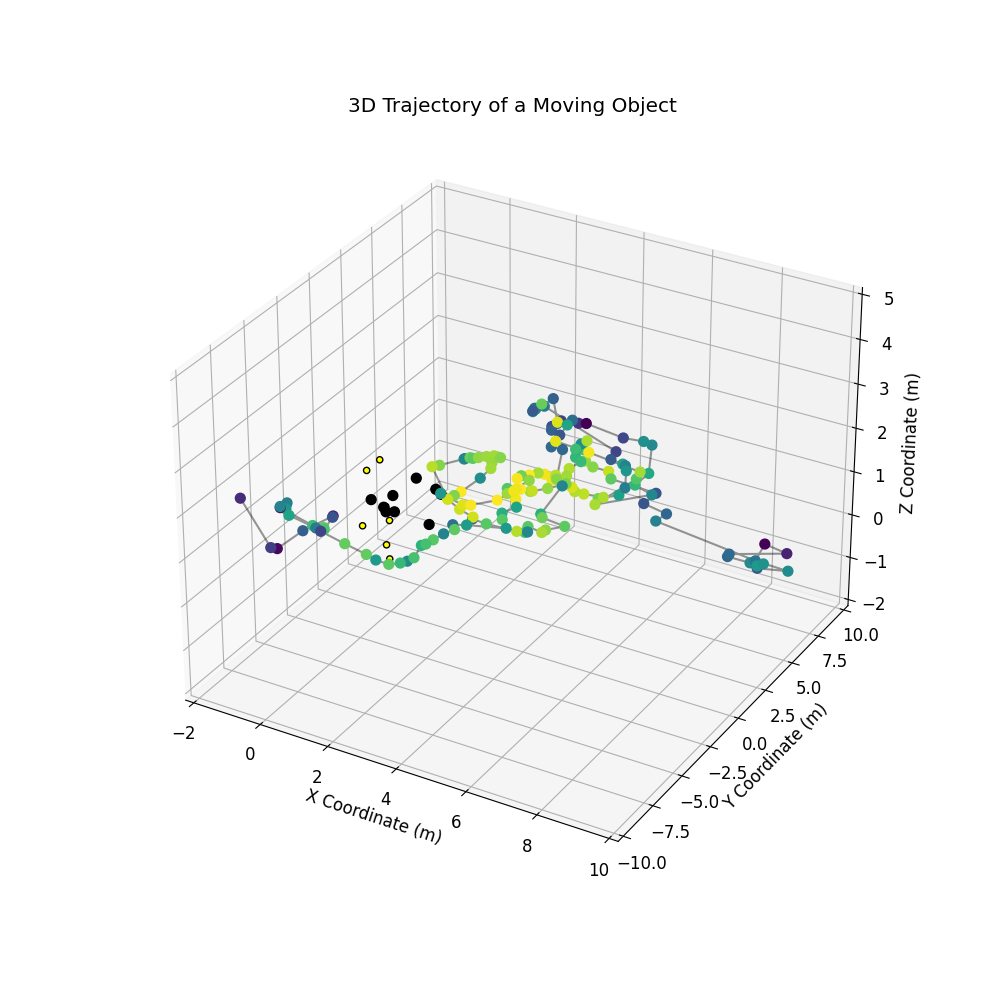

In [18]:
%matplotlib widget

fig = plt.figure(figsize=(10, 10))
plt.rcParams.update({'font.size': 12})
ax = fig.add_subplot(projection='3d')
ax.cla()

cmap = plt.get_cmap('viridis')
map_vals = (valid_dets_outside_unit_circle['SNR'])
color_vals = np.linspace(start, start+length, src_points_with_valid_speeds.shape[1])
norm = plt.Normalize(map_vals.min(), map_vals.max())
line_colors = cmap(norm(map_vals))

scatter = ax.scatter([], [], [], alpha=1, s=50)
line, = ax.plot([], [], [], color='k', alpha=0.4)

def update(frame):
    ax.cla()  # Clear the axis
    
    # Redraw the scatter points up to the current frame
    ax.scatter(
        valid_speed_src_points_outside_unit_circle[0, :frame],
        valid_speed_src_points_outside_unit_circle[1, :frame],
        valid_speed_src_points_outside_unit_circle[2, :frame],
        color=line_colors[:frame],
        alpha=1,
        s=50,
    )
    
    # Redraw the trajectory line up to the current frame
    ax.plot(
        valid_speed_src_points_outside_unit_circle[0, :frame],
        valid_speed_src_points_outside_unit_circle[1, :frame],
        valid_speed_src_points_outside_unit_circle[2, :frame],
        color='k',
        alpha=0.4,
    )

    ax.scatter(src_points_with_valid_speeds[0, ~ellipse_based_indices], src_points_with_valid_speeds[1, ~ellipse_based_indices],
        src_points_with_valid_speeds[2, ~ellipse_based_indices], color='k', alpha=1, s=50)
    ax.scatter(xs=A_locs_mat_tdoa_meters[:,0], ys=A_locs_mat_tdoa_meters[:,1], zs=A_locs_mat_tdoa_meters[:,2], facecolor='yellow', edgecolor='k', alpha=1)
    ax.scatter(xs=0, ys=0, zs=0, facecolor='yellow', edgecolor='k', alpha=1)
    
    # Restore axis labels and title after clearing
    ax.set_xlabel('X Coordinate (m)')
    ax.set_ylabel('Y Coordinate (m)')
    ax.set_zlabel('Z Coordinate (m)')
    ax.set_title('3D Trajectory of a Moving Object')
    ax.set_xlim([-2, 10])
    ax.set_ylim([-10, 10])
    ax.set_zlim([-2, 5])


num_frames = src_points_with_valid_speeds.shape[1]
ani = animation.FuncAnimation(fig, update, frames=num_frames, interval=50)

video_filename = f'20241215__UBNA1010deployment_3d_trajectory_{file_offset}.mp4'
ani.save(video_filename, writer='ffmpeg', fps=20)

print(f"Animation saved as {video_filename}")
plt.show()